# LE BOOTSTRAP (RÉÉCHANTILLONNAGE)

Notebook pédagogique généré à partir du contenu fourni.

Objectif : comprendre le **Bootstrap** comme un outil pratique pour répondre à une question de trader :

> Est-ce que le profit observé dans mon backtest est vraiment spécial, ou est-ce qu'une stratégie sans edge aurait pu produire un résultat similaire par hasard ?

Dans ce notebook, on va construire l'intuition pas à pas, puis coder un mini-test bootstrap complet.


## 1. L'idée EUREKA du Bootstrap

Imagine que tu as seulement **un seul historique de trading**. C'est frustrant, parce que tu aimerais savoir ce qui aurait pu se passer dans d'autres versions du passé.

Le Bootstrap répond :

> « Je ne peux pas créer de nouvelles vraies données, mais je peux recycler les observations passées pour simuler beaucoup de passés possibles. »

La mécanique est simple :

1. Tu prends les rendements journaliers de ta stratégie.
2. Tu les ajustes pour représenter l'hypothèse nulle : **aucun edge**, moyenne égale à zéro.
3. Tu tires au hasard, avec remise, autant de rendements que dans le backtest original.
4. Tu calcules la moyenne simulée.
5. Tu répètes cela des milliers de fois.
6. Tu compares ton vrai résultat à cette distribution de résultats imaginaires.

Si ton vrai profit est plus élevé que presque tous les profits simulés sous hasard pur, alors tu as une preuve statistique plus solide.


## 2. Les trois mots à ne jamais confondre

### Bootstrap
Méthode de rééchantillonnage : on tire au hasard dans les données existantes, avec remise.

### Zero-Centering
On soustrait la moyenne observée à chaque rendement. Résultat : la moyenne devient exactement zéro. Cela crée un monde conforme à $H_0$ : « la stratégie n'a pas de talent ».

### p-value
Fraction des simulations bootstrap qui font aussi bien ou mieux que ton backtest réel.

En trading :

> p-value = fréquence à laquelle une stratégie sans edge pourrait produire un résultat aussi bon que celui observé.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Pour rendre les résultats reproductibles
rng = np.random.default_rng(42)


## 3. Créons un exemple de stratégie

On simule une stratégie avec :

- 500 jours de trading,
- une volatilité journalière réaliste,
- un petit edge moyen positif.

Ici, ce n'est pas une recommandation de paramètres. C'est un laboratoire pédagogique.


In [2]:
# Paramètres pédagogiques
n_days = 500
true_daily_edge = 0.00025      # 0,025 % par jour
vol_daily = 0.01               # 1 % de volatilité journalière

# Rendements journaliers simulés de la règle
returns = rng.normal(loc=true_daily_edge, scale=vol_daily, size=n_days)

observed_mean = returns.mean()
annualized_return = observed_mean * 252

print(f"Moyenne journalière observée : {observed_mean:.5%}")
print(f"Rendement annualisé observé approximatif : {annualized_return:.2%}")


Moyenne journalière observée : 0.01187%
Rendement annualisé observé approximatif : 2.99%


## 4. Visualisons les rendements de la stratégie

Avant le test, on regarde simplement les rendements journaliers observés.


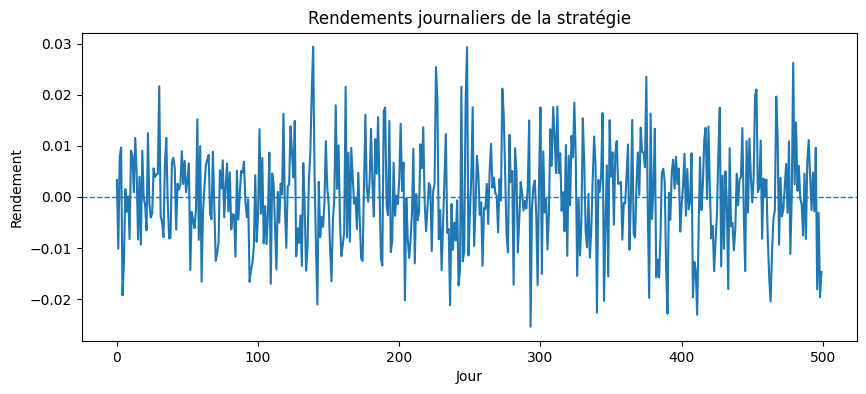

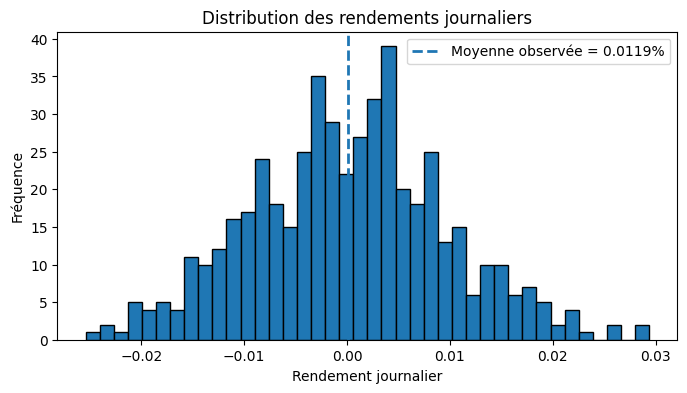

In [3]:
plt.figure(figsize=(10, 4))
plt.plot(returns)
plt.axhline(0, linestyle='--', linewidth=1)
plt.title("Rendements journaliers de la stratégie")
plt.xlabel("Jour")
plt.ylabel("Rendement")
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(returns, bins=40, edgecolor='black')
plt.axvline(observed_mean, linestyle='--', linewidth=2, label=f"Moyenne observée = {observed_mean:.4%}")
plt.title("Distribution des rendements journaliers")
plt.xlabel("Rendement journalier")
plt.ylabel("Fréquence")
plt.legend()
plt.show()


## 5. Étape cruciale : Zero-Centering

C'est ici que beaucoup de traders se trompent.

On ne bootstrap pas directement les rendements profitables si on veut tester l'hypothèse nulle. Pourquoi ?

Parce que si on laisse le profit moyen dedans, nos simulations contiennent déjà l'edge qu'on cherche à tester.

Donc on retire la moyenne observée :

$$
\text{rendement ajusté} = \text{rendement original} - \text{moyenne observée}
$$

Après ça, la moyenne est zéro. On obtient un panier de rendements représentant une stratégie sans talent, mais avec la même volatilité et la même forme approximative que les données observées.


In [4]:
zero_centered_returns = returns - observed_mean

print(f"Moyenne avant zero-centering : {returns.mean():.10%}")
print(f"Moyenne après zero-centering : {zero_centered_returns.mean():.10%}")
print(f"Volatilité avant : {returns.std(ddof=1):.4%}")
print(f"Volatilité après : {zero_centered_returns.std(ddof=1):.4%}")


Moyenne avant zero-centering : 0.0118738495%
Moyenne après zero-centering : -0.0000000000%
Volatilité avant : 0.9599%
Volatilité après : 0.9599%


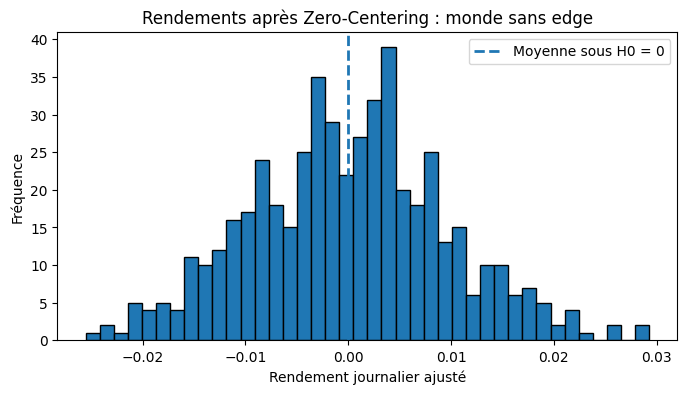

In [5]:
plt.figure(figsize=(8, 4))
plt.hist(zero_centered_returns, bins=40, edgecolor='black')
plt.axvline(0, linestyle='--', linewidth=2, label="Moyenne sous H0 = 0")
plt.title("Rendements après Zero-Centering : monde sans edge")
plt.xlabel("Rendement journalier ajusté")
plt.ylabel("Fréquence")
plt.legend()
plt.show()


## 6. Bootstrap : créer 5 000 mondes alternatifs

Chaque simulation répond à cette question :

> Si la stratégie n'avait aucun edge, quelle moyenne aurait-on pu obtenir juste par hasard ?

On tire donc 500 rendements avec remise dans le panier zero-centered, puis on calcule la moyenne. On répète 5 000 fois.


In [6]:
n_bootstrap = 5_000
bootstrap_means = np.empty(n_bootstrap)

for i in range(n_bootstrap):
    sample = rng.choice(zero_centered_returns, size=n_days, replace=True)
    bootstrap_means[i] = sample.mean()

bootstrap_annualized = bootstrap_means * 252

print(f"Nombre de simulations bootstrap : {n_bootstrap}")
print(f"Moyenne des moyennes simulées : {bootstrap_means.mean():.6%}")
print(f"Écart-type des moyennes simulées : {bootstrap_means.std(ddof=1):.6%}")


Nombre de simulations bootstrap : 5000
Moyenne des moyennes simulées : 0.000493%
Écart-type des moyennes simulées : 0.042681%


## 7. Calcul de la p-value

On mesure la fraction des mondes sans edge qui ont produit une moyenne au moins aussi bonne que celle du backtest réel.

Pour un test unilatéral à droite :

$$
p\text{-value} = P(\text{moyenne simulée} \geq \text{moyenne observée} \mid H_0)
$$


In [7]:
p_value = np.mean(bootstrap_means >= observed_mean)
critical_95 = np.percentile(bootstrap_means, 95)

print(f"Moyenne observée réelle : {observed_mean:.5%}")
print(f"Seuil critique 95 % sous H0 : {critical_95:.5%}")
print(f"p-value bootstrap : {p_value:.4f}")

if p_value < 0.05:
    print("Décision : résultat statistiquement significatif au seuil 5 %. On rejette H0.")
else:
    print("Décision : pas assez de preuve au seuil 5 %. On ne rejette pas H0.")


Moyenne observée réelle : 0.01187%
Seuil critique 95 % sous H0 : 0.06920%
p-value bootstrap : 0.3978
Décision : pas assez de preuve au seuil 5 %. On ne rejette pas H0.


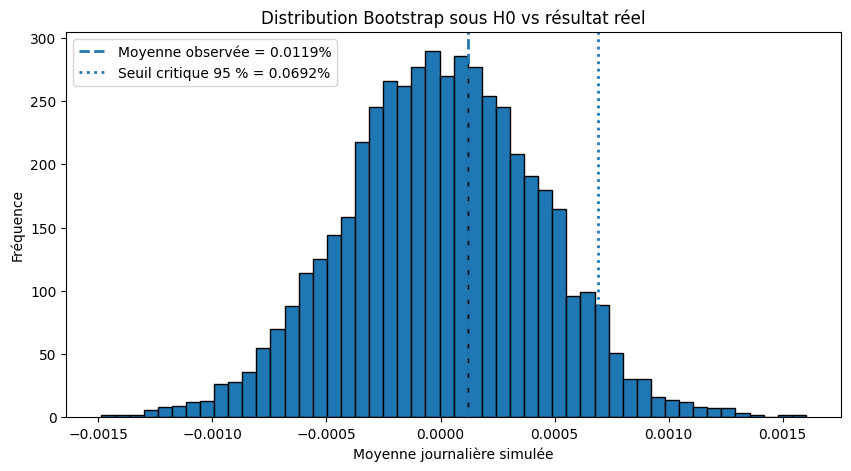

In [8]:
plt.figure(figsize=(10, 5))
plt.hist(bootstrap_means, bins=50, edgecolor='black')
plt.axvline(observed_mean, linestyle='--', linewidth=2, label=f"Moyenne observée = {observed_mean:.4%}")
plt.axvline(critical_95, linestyle=':', linewidth=2, label=f"Seuil critique 95 % = {critical_95:.4%}")
plt.title("Distribution Bootstrap sous H0 vs résultat réel")
plt.xlabel("Moyenne journalière simulée")
plt.ylabel("Fréquence")
plt.legend()
plt.show()


## 8. Interprétation trading

La distribution bootstrap représente ce que le hasard peut produire quand la stratégie n'a aucun talent.

Ton résultat réel est comparé à ce benchmark.

- Si le résultat réel est dans la zone centrale : il n'est pas spécial.
- S'il est dans l'extrême droite : il devient difficile d'expliquer ce résultat par la chance seule.
- La p-value quantifie exactement cette rareté.

Phrase à retenir :

> Le Bootstrap ne prouve pas que la stratégie marchera demain. Il mesure à quel point le backtest est difficile à expliquer par le hasard.


## 9. Fonction réutilisable pour tes backtests

Voici une fonction que tu peux réutiliser avec tes propres rendements journaliers de stratégie.


In [9]:
def bootstrap_p_value(returns, n_bootstrap=5_000, seed=42):
    """
    Calcule une p-value bootstrap unilatérale à droite pour une stratégie de trading.

    Paramètres
    ----------
    returns : array-like
        Rendements journaliers de la stratégie.
    n_bootstrap : int
        Nombre de rééchantillonnages bootstrap.
    seed : int
        Graine aléatoire pour reproductibilité.

    Retourne
    --------
    dict
        Moyenne observée, seuil critique 95 %, p-value et distribution simulée.
    """
    returns = np.asarray(returns, dtype=float)
    rng = np.random.default_rng(seed)

    observed_mean = returns.mean()
    zero_centered = returns - observed_mean
    n = len(returns)

    boot_means = np.empty(n_bootstrap)
    for i in range(n_bootstrap):
        sample = rng.choice(zero_centered, size=n, replace=True)
        boot_means[i] = sample.mean()

    p_value = np.mean(boot_means >= observed_mean)
    critical_95 = np.percentile(boot_means, 95)

    return {
        "observed_mean": observed_mean,
        "annualized_observed_mean": observed_mean * 252,
        "critical_95": critical_95,
        "p_value": p_value,
        "bootstrap_means": boot_means,
    }

result = bootstrap_p_value(returns)
result_summary = {k: v for k, v in result.items() if k != "bootstrap_means"}
result_summary


{'observed_mean': np.float64(0.00011873849533066123),
 'annualized_observed_mean': np.float64(0.02992210082332663),
 'critical_95': np.float64(0.0007041795989819864),
 'p_value': np.float64(0.4044)}

## 10. Exemple : stratégie sans edge

Maintenant, regardons ce qui se passe quand la stratégie n'a vraiment aucun edge.

Normalement, la p-value devrait souvent être non significative. Pas toujours, parce que les faux positifs existent, mais souvent.


In [10]:
no_edge_returns = rng.normal(loc=0.0, scale=vol_daily, size=n_days)
no_edge_result = bootstrap_p_value(no_edge_returns, seed=123)

print(f"Moyenne observée sans edge : {no_edge_result['observed_mean']:.5%}")
print(f"Rendement annualisé observé : {no_edge_result['annualized_observed_mean']:.2%}")
print(f"p-value bootstrap : {no_edge_result['p_value']:.4f}")


Moyenne observée sans edge : 0.06334%
Rendement annualisé observé : 15.96%
p-value bootstrap : 0.0830


## 11. Les erreurs classiques à éviter

### Erreur 1 : bootstrapper les rendements bruts sans zero-centering
Tu simules alors un monde qui contient déjà le profit observé. Ce n'est plus un test propre de $H_0$.

### Erreur 2 : croire qu'une p-value faible garantit le futur
Une p-value faible dit seulement : « ce backtest est difficile à expliquer par hasard sous ce protocole ». Elle ne protège pas contre le sur-ajustement, les frais oubliés, le slippage, le changement de régime ou le data mining.

### Erreur 3 : utiliser le bootstrap classique après avoir testé des milliers de règles
Si tu as cherché parmi beaucoup de règles, la meilleure règle aura souvent eu de la chance. Dans ce cas, il faut une correction de type **White's Reality Check** ou une procédure adaptée au data mining.

### Erreur 4 : ignorer la dépendance temporelle
Le bootstrap simple tire les jours indépendamment. Pour des séries avec forte autocorrélation, il faut parfois un **block bootstrap**, qui rééchantillonne des blocs de jours plutôt que des jours isolés.


## 12. Mini-exercice pour bien ancrer

Change ces valeurs dans le notebook et observe la p-value :

- `true_daily_edge` : augmente ou baisse le vrai edge.
- `vol_daily` : augmente la volatilité.
- `n_days` : augmente ou baisse la taille du backtest.

Tu vas voir une intuition importante :

> Plus l'edge est petit, plus la volatilité est grande, ou plus l'échantillon est court, plus il devient difficile de distinguer le talent de la chance.


## 13. Résumé final

Le Bootstrap est un outil pour construire une distribution du hasard à partir de tes propres données.

Dans le protocole EBTA :

1. On part des rendements de la règle.
2. On applique le zero-centering pour rendre les données conformes à $H_0$.
3. On rééchantillonne avec remise.
4. On calcule des milliers de moyennes simulées.
5. On compare le vrai backtest à cette distribution.
6. On obtient une p-value.

Formule mentale :

> Backtest réel contre univers parallèles sans edge.

C'est ça le Bootstrap.


---

## Annexe : contenu source fourni

Le texte ci-dessous est le contenu de départ utilisé pour construire ce notebook.


### **LE BOOTSTRAP (RÉÉCHANTILLONNAGE)**

Voici l’analyse technique du Bootstrap, une méthode informatique intensive utilisée en Analyse Technique Objective pour quantifier l'incertitude et valider les signaux de trading.

#### **Idées clés :**
*   **Recyclage des données :** Le Bootstrap permet d'approximer la forme de la distribution d'échantillonnage à partir d'un seul échantillon historique en réutilisant systématiquement les données originales.
*   **Rééchantillonnage avec remise :** Le mécanisme repose sur le tirage aléatoire d'observations où chaque donnée peut être sélectionnée plusieurs fois ou jamais (*resampling with replacement*).
*   **Conformité à l'Hypothèse Nulle :** Pour tester une règle, les données doivent être ajustées par le « Zero-Centering » afin de simuler une stratégie sans aucun talent (moyenne = 0).
*   **Convergence mathématique :** Le « Bootstrap Theorem » garantit que la distribution simulée converge vers la distribution réelle à mesure que la taille de l'échantillon augmente.

---

#### **Référence :**
*The Bootstrap* (Pages 235–238) ; *Testing Rule Performance Using Bootstrap* (Pages 241–242).

---

#### **Citation Directe :**
« The bootstrap derives a sampling distribution of the test statistic by resampling with replacement from an original sample. » (Page 235).
*(Traduction : Le bootstrap dérive une distribution d'échantillonnage de la statistique de test par rééchantillonnage avec remise à partir d'un échantillon original.)*

---

#### **Vision Macro :**
L'enjeu est de briser la limite du « passé unique ». En trading, nous ne disposons que d'un seul historique de prix, ce qui ne permet pas de savoir si un profit de backtest est une fluctuation normale du hasard ou un avantage réel. Le Bootstrap agit comme un créateur d'univers parallèles : il « soulève » les données par leurs propres lacets (d'où son nom *bootstraps*) pour simuler des milliers de variantes du passé. Cela permet de construire un **étalon du hasard** (benchmark) sur mesure pour chaque stratégie.

---

#### **Vision Micro : Le Processus Détaillé**
Pour tester une règle de trading, le processus suit ces étapes rigoureuses :

1.  **Préparation (Données Detrendées) :** On commence avec les rendements quotidiens obtenus sur des données de marché dont la tendance a été retirée.
2.  **Ajustement (Zero-Centering) :** On calcule le profit moyen du backtest et on le soustrait de chaque rendement quotidien. La nouvelle moyenne de cet échantillon est alors de 0,0 %, ce qui le rend conforme à l'Hypothèse Nulle ($H_0$).
3.  **Tirage Aléatoire ($N$ fois) :** L'ordinateur pioche au hasard une donnée dans cet échantillon ajusté, note sa valeur, et la remet dans le "panier". On répète l'opération exactement $N$ fois (où $N$ est la taille de l'échantillon original).
4.  **Calcul de la Moyenne :** On calcule la moyenne de ce nouvel échantillon artificiel.
5.  **Itérations Massives :** On répète les étapes 3 et 4 un grand nombre de fois (généralement 5 000 itérations).
6.  **Inférence (p-value) :** On compare le profit réel du backtest à cette distribution de 5 000 moyennes. La p-value est la fraction de ces moyennes simulées qui sont supérieures ou égales au profit réel.

---

#### **Résumé Simplifié :**
Le Bootstrap est un "recycleur de données". Il prend vos résultats de trading, en retire tout le profit pour ne garder que le risque et le hasard, puis mélange le tout pour créer 5 000 backtests imaginaires de "chance pure". Si votre vrai profit est meilleur que 95 % de ces tests imaginaires, alors votre stratégie a probablement un vrai talent.

---

#### **Exemple du livre : La Règle TT-4-91**
David Aronson teste une cassure de canal sur 91 jours qui affiche un rendement de **+4,84 %**. 
*   Après le processus Bootstrap (5 000 itérations), il obtient une p-value de **0,0692**.
*   Cela signifie que dans environ 7 cas sur 100, une règle totalement inutile aurait pu obtenir ce profit par pur hasard d'échantillonnage.
*   Le résultat est jugé « possiblement significatif », mais pas assez robuste selon les standards les plus stricts (p < 0,05).

---

#### **Actions Concrètes :**
*   **Utilisez 5 000 itérations :** C'est le standard pour obtenir une distribution stable et une p-value fiable.
*   **Vérifiez la taille N :** Chaque échantillon simulé doit avoir exactement le même nombre de jours que votre backtest original pour respecter le théorème du Bootstrap.
*   **Ne pas l'utiliser brut pour le Data Mining :** Le bootstrap classique ne traite que l'évaluation d'une seule règle. Si vous testez des milliers de règles, vous devez impérativement utiliser le **White’s Reality Check** (une modification du Bootstrap) pour éviter les faux positifs causés par le biais de minage de données.

---

#### **À retenir absolument :**
*   C'est une méthode de **rééchantillonnage avec remise**.
*   Le **Zero-Centering** est l'étape mathématique la plus importante pour tester $H_0$.
*   Il permet de calculer la **p-value** sans assumer que les données suivent une loi normale.
*   Il transforme un fait unique (le backtest) en une **probabilité de réussite future**.
*   C'est le moteur du **White's Reality Check** pour éliminer la chance en trading.

J'ai terminé l'analyse de la méthode Bootstrap selon le protocole EBTA.
